# 05 - Budget Expenditure Prediction

## Objective

Build and compare three regression proof-of-concept models for predicting budget `Expenditure` from historical budget information. Evaluation is chronological: train on earlier available years and test on the latest year. The processed dataset contains only three annual periods, so results are limited and must not be treated as a reliable long-term forecasting system.

This notebook uses only `data/processed/budget_features.csv`. It does not merge other datasets, create future years, randomly split the data, or train on `Expenditure_to_Release_Pct`.

## 1. Imports and Configuration

Import data, plotting, metric, preprocessing, pipeline, estimator, and serialization utilities. Define all input and output paths relative to the notebook and project root.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from IPython.display import display

working_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (working_directory, *working_directory.parents)
        if (candidate / "notebooks").is_dir()
        and (candidate / "data" / "processed").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Could not locate the project root from {working_directory}"
    )

notebook_directory = project_root / "notebooks"
processed_data_directory = (notebook_directory / ".." / "data" / "processed").resolve()
budget_data_path = processed_data_directory / "budget_features.csv"
predictions_directory = (notebook_directory / ".." / "outputs" / "predictions").resolve()
reports_directory = (notebook_directory / ".." / "outputs" / "reports").resolve()
graphs_directory = (notebook_directory / ".." / "outputs" / "graphs").resolve()
models_directory = (notebook_directory / ".." / "models").resolve()

print(f"Project root: {project_root}")
print(f"Budget feature input: {budget_data_path}")
print(
    f"pandas={pd.__version__}; numpy={np.__version__}; "
    f"scikit-learn={sklearn.__version__}; xgboost={xgboost.__version__}"
)

Project root: C:\Users\bagad\health-budget-ml
Budget feature input: C:\Users\bagad\health-budget-ml\data\processed\budget_features.csv
pandas=3.0.6; numpy=2.5.3; scikit-learn=1.9.1; xgboost=3.4.1


## 2. Load Processed Budget Data

Read only the engineered budget dataset. Inspect its dimensions, fields, types, and missing values before defining the prediction target or removing any rows.

In [2]:
if not budget_data_path.is_file():
    raise FileNotFoundError(f"Processed budget dataset not found: {budget_data_path}")
budget = pd.read_csv(budget_data_path)
if budget.empty:
    raise ValueError("Processed budget dataset has no rows.")

print(f"Shape: {budget.shape}")
print(f"Columns: {list(budget.columns)}")
print("First 5 rows:")
display(budget.head(5))
print("Data types:")
display(budget.dtypes.rename("dtype").to_frame())
print("Missing values:")
budget_missing = budget.isna().sum().rename("missing_count").to_frame()
budget_missing["missing_percent"] = budget.isna().mean().mul(100).round(2)
display(budget_missing)
print("Available financial years:", sorted(budget["Year"].dropna().astype(str).unique()))
print("Available numeric years:", sorted(budget["Year_Numeric"].dropna().astype(int).unique()))
print("Number of states:", budget["State"].nunique(dropna=True))

Shape: (108, 8)
Columns: ['State', 'Year', 'Year_Numeric', 'Central_Release', 'Expenditure_to_Release_Pct', 'Previous_Year_Expenditure', 'Previous_Year_Central_Release', 'Expenditure']
First 5 rows:


,State,Year,Year_Numeric,Central_Release,Expenditure_to_Release_Pct,Previous_Year_Expenditure,Previous_Year_Central_Release,Expenditure
0,Andaman and Nicobar Islands,2021-22,2021,43.68,71.428571,NaN,NaN,31.20
1,Andaman and Nicobar Islands,2022-23,2022,45.26,93.415820,31.20,43.68,42.28
2,Andaman and Nicobar Islands,2023-24,2023,37.84,107.584567,42.28,45.26,40.71
3,Andhra Pradesh,2021-22,2021,1199.37,204.163019,NaN,NaN,2448.67
4,Andhra Pradesh,2022-23,2022,1489.45,128.526637,2448.67,1199.37,1914.34


Data types:


,dtype
State,str
Year,str
Year_Numeric,int64
Central_Release,float64
Expenditure_to_Release_Pct,float64
Previous_Year_Expenditure,float64
Previous_Year_Central_Release,float64
Expenditure,float64


Missing values:


,missing_count,missing_percent
State,0,0.00
Year,0,0.00
Year_Numeric,0,0.00
Central_Release,0,0.00
Expenditure_to_Release_Pct,0,0.00
Previous_Year_Expenditure,36,33.33
Previous_Year_Central_Release,36,33.33
Expenditure,0,0.00


Available financial years: ['2021-22', '2022-23', '2023-24']
Available numeric years: [np.int64(2021), np.int64(2022), np.int64(2023)]
Number of states: 36


## 3. Define Predictors and Target

Use the requested historical predictors and set `Expenditure` as the sole target. Keep the current-year spending-to-release ratio out of `X`: it is derived from current expenditure and would reveal the target.

In [3]:
target_column = "Expenditure"
predictor_columns = [
    "State",
    "Year_Numeric",
    "Central_Release",
    "Previous_Year_Expenditure",
    "Previous_Year_Central_Release",
]
required_columns = predictor_columns + [target_column]
missing_required_columns = sorted(set(required_columns).difference(budget.columns))
if missing_required_columns:
    raise ValueError(f"Required model columns are missing: {missing_required_columns}")

X = budget[predictor_columns].copy()
y = budget[target_column].copy()
assert target_column not in X.columns
assert "Expenditure_to_Release_Pct" not in X.columns
assert len(X) == len(y)

ratio_formula_check = np.isclose(
    budget["Expenditure_to_Release_Pct"],
    budget["Expenditure"] / budget["Central_Release"] * 100,
    rtol=1e-6,
    atol=1e-6,
)
print(f"X predictors: {list(X.columns)}")
print(f"y target: {target_column}")
print(f"Expenditure in X: {'Expenditure' in X.columns}")
print(
    "Expenditure_to_Release_Pct in X: "
    f"{'Expenditure_to_Release_Pct' in X.columns}"
)
print(
    "Rows where the ratio matches current Expenditure / Central_Release * 100: "
    f"{int(ratio_formula_check.sum())} of {len(budget)}"
)
if ratio_formula_check.all():
    print("Leakage check: current-year ratio is target-derived and is excluded from X.")
print(f"Predictor matrix shape: {X.shape}; target shape: {y.shape}")

X predictors: ['State', 'Year_Numeric', 'Central_Release', 'Previous_Year_Expenditure', 'Previous_Year_Central_Release']
y target: Expenditure
Expenditure in X: False
Expenditure_to_Release_Pct in X: False
Rows where the ratio matches current Expenditure / Central_Release * 100: 108 of 108
Leakage check: current-year ratio is target-derived and is excluded from X.
Predictor matrix shape: (108, 5); target shape: (108,)


## 4. Prepare Data and Chronological Split

Do not fill missing lag values. Remove a row only when a required predictor or target is unavailable, and report the count and years affected. Then use every earlier complete year for training and the latest complete year for testing; no random split is used.

In [4]:
predictors_available = X.notna().all(axis=1)
target_available = y.notna()
complete_rows = predictors_available & target_available
rows_removed = int((~complete_rows).sum())
removed_year_counts = (
    budget.loc[~complete_rows, "Year_Numeric"].value_counts(dropna=False).sort_index()
)
print(f"Rows before required-field filtering: {len(budget)}")
print(f"Rows removed because required predictors/target are unavailable: {rows_removed}")
print(f"Removed rows by Year_Numeric: {removed_year_counts.to_dict()}")

X_model = X.loc[complete_rows].copy()
y_model = y.loc[complete_rows].copy()
model_metadata = budget.loc[complete_rows, ["State", "Year", "Year_Numeric"]].copy()
categorical_features = ["State"]
numeric_features = [
    "Year_Numeric",
    "Central_Release",
    "Previous_Year_Expenditure",
    "Previous_Year_Central_Release",
]
print(f"Rows retained for chronological evaluation: {len(X_model)}")
print(f"State remains a categorical input for OneHotEncoder: {categorical_features}")

available_model_years = sorted(X_model["Year_Numeric"].astype(int).unique().tolist())
if len(available_model_years) < 2:
    raise ValueError("At least two complete years are required for chronological evaluation.")
test_year = available_model_years[-1]
training_years = [year for year in available_model_years if year < test_year]
train_mask = X_model["Year_Numeric"].isin(training_years)
test_mask = X_model["Year_Numeric"].eq(test_year)
if not train_mask.any() or not test_mask.any():
    raise ValueError("Chronological split produced an empty training or test set.")

X_train = X_model.loc[train_mask].copy()
X_test = X_model.loc[test_mask].copy()
y_train = y_model.loc[train_mask].copy()
y_test = y_model.loc[test_mask].copy()
test_metadata = model_metadata.loc[test_mask, ["State", "Year"]].copy()
assert max(training_years) < test_year

print(f"Training years: {training_years}")
print(f"Testing year: {test_year}")
print(f"Training rows: {len(X_train)}; test rows: {len(X_test)}")
print(
    "Limitation: only one complete training year precedes the held-out year "
    "in this three-period dataset; this is a limited proof-of-concept evaluation."
)

Rows before required-field filtering: 108
Rows removed because required predictors/target are unavailable: 36
Removed rows by Year_Numeric: {2021: 36}
Rows retained for chronological evaluation: 72
State remains a categorical input for OneHotEncoder: ['State']
Training years: [2022]
Testing year: 2023
Training rows: 36; test rows: 36
Limitation: only one complete training year precedes the held-out year in this three-period dataset; this is a limited proof-of-concept evaluation.


## 5. Preprocessing and Model Pipelines

Keep preprocessing inside each scikit-learn `Pipeline`, so encoders and scalers fit only on training rows. `State` is one-hot encoded with unknown categories ignored. Linear Regression scales numeric predictors; tree models use numeric values without scaling.

In [5]:
def make_preprocessor(scale_numeric):
    numeric_transformer = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        transformers=[
            (
                "state",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features,
            ),
            ("numeric", numeric_transformer, numeric_features),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

pipelines = {
    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(scale_numeric=True)),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(scale_numeric=False)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=150,
                    max_depth=3,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=1,
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(scale_numeric=False)),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    n_estimators=60,
                    max_depth=2,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_lambda=2.0,
                    eval_metric="rmse",
                    random_state=42,
                    n_jobs=1,
                    verbosity=0,
                ),
            ),
        ]
    ),
}
print("Pipelines configured:", list(pipelines))
print("All pipelines preprocess State with OneHotEncoder(handle_unknown='ignore').")

Pipelines configured: ['Linear Regression', 'Random Forest', 'XGBoost']
All pipelines preprocess State with OneHotEncoder(handle_unknown='ignore').


## 6. Train and Evaluate Chronologically

Fit all preprocessing and estimators on the 2022 training rows only, then predict the held-out 2023 rows. Compare MAE, RMSE, and R². MAPE is omitted; the small, limited time range makes absolute-error metrics easier to interpret here.

In [6]:
trained_pipelines = {}
predictions_by_model = {}
prediction_frames = []
metric_rows = []

for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    predicted_expenditure = pipeline.predict(X_test)
    trained_pipelines[model_name] = pipeline
    predictions_by_model[model_name] = predicted_expenditure

    metric_rows.append(
        {
            "Model": model_name,
            "MAE": mean_absolute_error(y_test, predicted_expenditure),
            "RMSE": np.sqrt(mean_squared_error(y_test, predicted_expenditure)),
            "R2": r2_score(y_test, predicted_expenditure),
        }
    )
    prediction_frames.append(
        pd.DataFrame(
            {
                "State": test_metadata["State"].to_numpy(),
                "Year": test_metadata["Year"].to_numpy(),
                "Actual_Expenditure": y_test.to_numpy(),
                "Predicted_Expenditure": predicted_expenditure,
                "Model": model_name,
            }
        )
    )

model_comparison = pd.DataFrame(metric_rows).sort_values("MAE").reset_index(drop=True)
predictions_dataframe = pd.concat(prediction_frames, ignore_index=True)
print("Chronological model comparison (lower MAE/RMSE is better; higher R2 is better):")
display(model_comparison.round(3))
print("Best by MAE:", model_comparison.loc[model_comparison["MAE"].idxmin(), "Model"])
print("Best by RMSE:", model_comparison.loc[model_comparison["RMSE"].idxmin(), "Model"])
print("Best by R2:", model_comparison.loc[model_comparison["R2"].idxmax(), "Model"])
print(f"Predictions generated for held-out year {test_year}: {len(test_metadata)} states per model.")

Chronological model comparison (lower MAE/RMSE is better; higher R2 is better):


,Model,MAE,RMSE,R2
0,Linear Regression,340.827,587.463,0.911
1,Random Forest,416.431,735.866,0.860
2,XGBoost,440.854,743.709,0.857


Best by MAE: Linear Regression
Best by RMSE: Linear Regression
Best by R2: Linear Regression
Predictions generated for held-out year 2023: 36 states per model.


## 7. Actual vs Predicted

Compare each model's predictions for the held-out 2023 period against actual expenditure. The dashed diagonal is the perfect-prediction reference; each point represents one State in the test year.

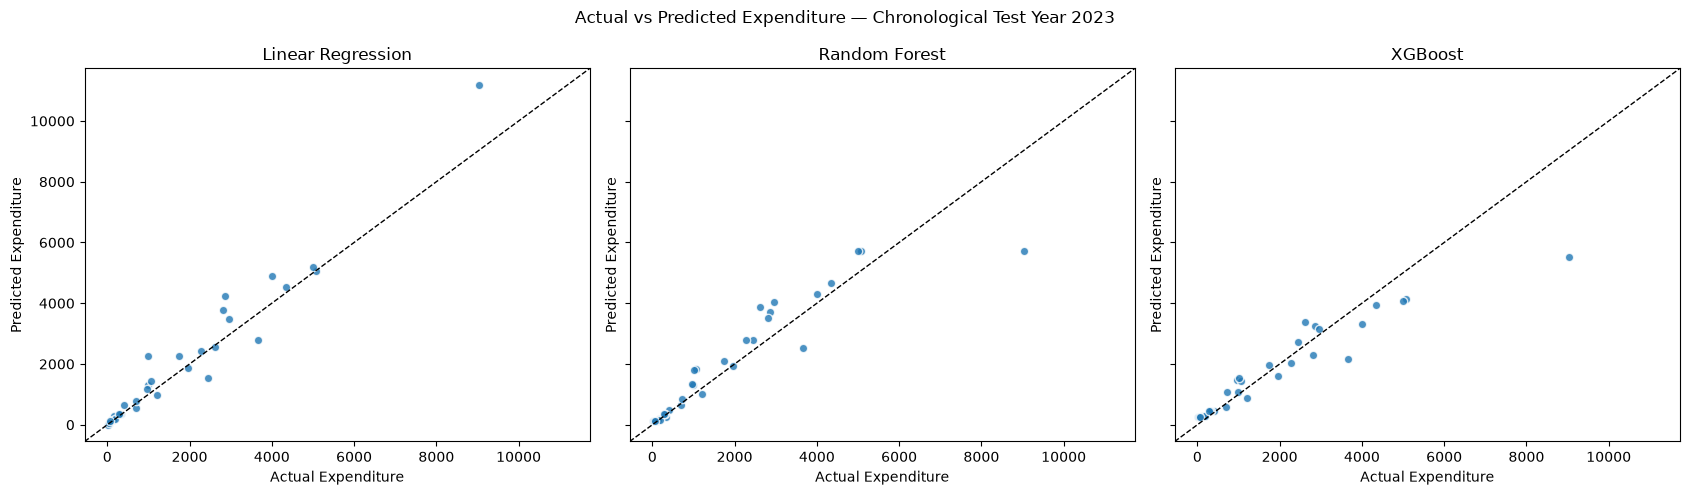

Saved plot to C:\Users\bagad\health-budget-ml\outputs\graphs\budget_actual_vs_predicted.png


In [7]:
graphs_directory.mkdir(parents=True, exist_ok=True)
actual_values = y_test.to_numpy()
all_prediction_values = np.concatenate(list(predictions_by_model.values()))
axis_min = float(min(actual_values.min(), all_prediction_values.min()))
axis_max = float(max(actual_values.max(), all_prediction_values.max()))
padding = max((axis_max - axis_min) * 0.05, 1.0)
plot_min = axis_min - padding
plot_max = axis_max + padding

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
for axis, (model_name, predicted_values) in zip(axes, predictions_by_model.items()):
    axis.scatter(actual_values, predicted_values, alpha=0.8, edgecolor="white")
    axis.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        color="black",
        linestyle="--",
        linewidth=1,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Actual Expenditure")
    axis.set_ylabel("Predicted Expenditure")
    axis.set_xlim(plot_min, plot_max)
    axis.set_ylim(plot_min, plot_max)
fig.suptitle(f"Actual vs Predicted Expenditure — Chronological Test Year {test_year}")
fig.tight_layout()
prediction_plot_path = graphs_directory / "budget_actual_vs_predicted.png"
fig.savefig(prediction_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved plot to {prediction_plot_path}")

## 8. Tree-Model Feature Importance

For Random Forest and XGBoost, inspect the fitted tree estimators' impurity/gain importance values using the transformed feature names from the fitted training-only preprocessor. These are descriptive, model-specific importances, not causal effects.

Random Forest: top feature importances


,Feature,Importance
0,numeric__Previous_Year_Expenditure,0.421789
1,numeric__Previous_Year_Central_Release,0.372400
2,numeric__Central_Release,0.205811
3,state__State_Andaman and Nicobar Islands,0.000000
4,state__State_Bihar,0.000000
5,state__State_Andhra Pradesh,0.000000
6,state__State_Arunachal Pradesh,0.000000
7,state__State_Assam,0.000000
8,state__State_Dadra and Nagar Haveli and Daman ...,0.000000
9,state__State_Chhattisgarh,0.000000


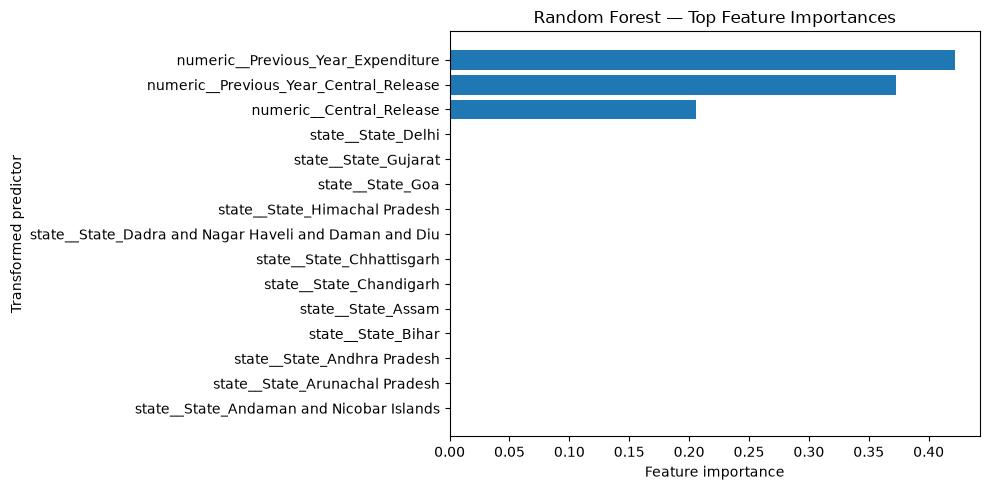

Saved feature-importance plot to C:\Users\bagad\health-budget-ml\outputs\graphs\random_forest_feature_importance.png
XGBoost: top feature importances


,Feature,Importance
0,numeric__Previous_Year_Central_Release,0.461025
1,numeric__Previous_Year_Expenditure,0.238583
2,numeric__Central_Release,0.129954
3,state__State_Uttar Pradesh,0.081215
4,state__State_Assam,0.044902
5,state__State_Karnataka,0.042031
6,state__State_Maharashtra,0.002076
7,state__State_Manipur,0.000214
8,state__State_Dadra and Nagar Haveli and Daman ...,0.000000
9,state__State_Chhattisgarh,0.000000


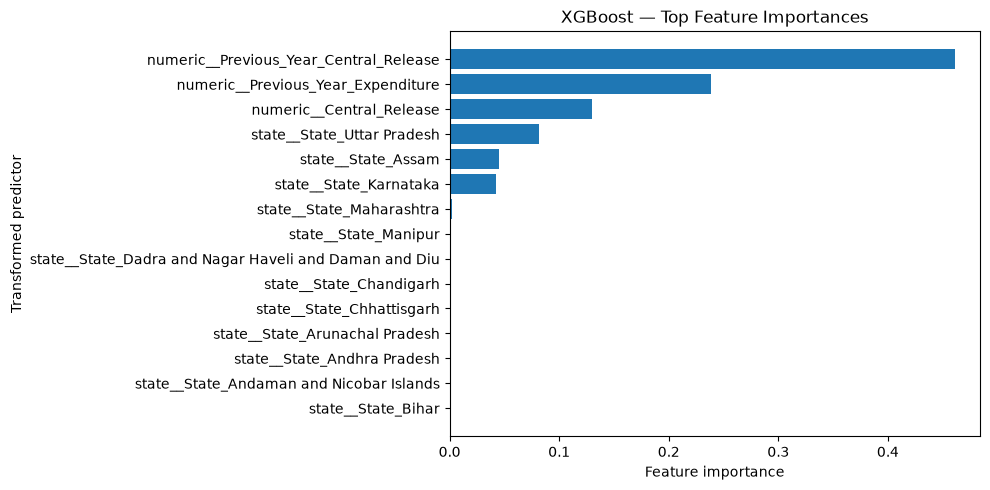

Saved feature-importance plot to C:\Users\bagad\health-budget-ml\outputs\graphs\xgboost_feature_importance.png


In [8]:
feature_importance_tables = {}
for model_name in ["Random Forest", "XGBoost"]:
    fitted_pipeline = trained_pipelines[model_name]
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    fitted_estimator = fitted_pipeline.named_steps["model"]
    transformed_feature_names = fitted_preprocessor.get_feature_names_out()
    importances = fitted_estimator.feature_importances_
    if len(transformed_feature_names) != len(importances):
        raise ValueError(f"Feature-name/importance count mismatch for {model_name}.")

    importance_table = (
        pd.DataFrame(
            {
                "Feature": transformed_feature_names,
                "Importance": importances,
            }
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    feature_importance_tables[model_name] = importance_table
    top_importances = importance_table.head(15).sort_values("Importance")
    print(f"{model_name}: top feature importances")
    display(importance_table.head(15))

    fig, ax = plt.subplots(figsize=(10, max(5, 0.32 * len(top_importances))))
    ax.barh(top_importances["Feature"], top_importances["Importance"])
    ax.set_title(f"{model_name} — Top Feature Importances")
    ax.set_xlabel("Feature importance")
    ax.set_ylabel("Transformed predictor")
    fig.tight_layout()
    importance_filename = (
        "random_forest_feature_importance.png"
        if model_name == "Random Forest"
        else "xgboost_feature_importance.png"
    )
    importance_path = graphs_directory / importance_filename
    fig.savefig(importance_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved feature-importance plot to {importance_path}")

## 9. Held-Out Predictions

The prediction table contains only the chronological test year and includes the State, financial Year, actual target, predicted target, and model name.

In [9]:
prediction_columns = [
    "State",
    "Year",
    "Actual_Expenditure",
    "Predicted_Expenditure",
    "Model",
]
predictions_dataframe = predictions_dataframe[prediction_columns].copy()
assert set(predictions_dataframe["Year"].unique()) == set(
    test_metadata["Year"].unique()
)
assert predictions_dataframe["Model"].nunique() == len(pipelines)
print(f"Predictions dataframe shape: {predictions_dataframe.shape}")
print("Rows per model:")
display(predictions_dataframe.groupby("Model").size().rename("rows").to_frame())
display(predictions_dataframe.head(12))

Predictions dataframe shape: (108, 5)
Rows per model:


,rows
Model,
Linear Regression,36
Random Forest,36
XGBoost,36


,State,Year,Actual_Expenditure,Predicted_Expenditure,Model
0,Andaman and Nicobar Islands,2023-24,40.71,44.792968,Linear Regression
1,Andhra Pradesh,2023-24,2436.62,1536.836349,Linear Regression
2,Arunachal Pradesh,2023-24,399.44,649.746531,Linear Regression
3,Assam,2023-24,2626.87,2549.318026,Linear Regression
4,Bihar,2023-24,4010.97,4904.131149,Linear Regression
5,Chandigarh,2023-24,31.85,33.594988,Linear Regression
6,Chhattisgarh,2023-24,1743.79,2257.771967,Linear Regression
7,Dadra and Nagar Haveli and Daman and Diu,2023-24,41.96,39.225785,Linear Regression
8,Delhi,2023-24,338.41,351.580183,Linear Regression
9,Goa,2023-24,82.44,109.892263,Linear Regression


## 10. Save Evaluation Outputs

Save predictions, metrics, and graphs to their project output folders. Save a reusable model only if the chronological dataset contains at least three complete years and at least two pre-test training years; otherwise retain evaluation artifacts only.

In [10]:
predictions_directory.mkdir(parents=True, exist_ok=True)
reports_directory.mkdir(parents=True, exist_ok=True)
graphs_directory.mkdir(parents=True, exist_ok=True)

predictions_output_path = predictions_directory / "budget_predictions.csv"
metrics_output_path = reports_directory / "budget_model_metrics.csv"
predictions_dataframe.to_csv(predictions_output_path, index=False)
model_comparison.to_csv(metrics_output_path, index=False)
print(f"Saved predictions: {predictions_output_path}")
print(f"Saved model metrics: {metrics_output_path}")
print(f"Saved graphs under: {graphs_directory}")

years_available_for_model = sorted(
    X_model["Year_Numeric"].astype(int).unique().tolist()
)
model_save_is_defensible = (
    len(years_available_for_model) >= 3 and len(training_years) >= 2
)
if model_save_is_defensible:
    selected_model_name = model_comparison.iloc[0]["Model"]
    selected_pipeline = trained_pipelines[selected_model_name]
    models_directory.mkdir(parents=True, exist_ok=True)
    selected_model_path = models_directory / "budget_model.joblib"
    joblib.dump(selected_pipeline, selected_model_path)
    print(
        f"Saved selected model ({selected_model_name}) to "
        f"{selected_model_path}"
    )
else:
    print(
        "No trained model was saved: only "
        f"{len(years_available_for_model)} complete annual period(s) and "
        f"{len(training_years)} pre-test training year(s) are available. "
        "That evaluation is not defensible for a reusable forecasting artifact."
    )

Saved predictions: C:\Users\bagad\health-budget-ml\outputs\predictions\budget_predictions.csv
Saved model metrics: C:\Users\bagad\health-budget-ml\outputs\reports\budget_model_metrics.csv
Saved graphs under: C:\Users\bagad\health-budget-ml\outputs\graphs
No trained model was saved: only 2 complete annual period(s) and 1 pre-test training year(s) are available. That evaluation is not defensible for a reusable forecasting artifact.


## 11. Model Interpretation and Limitations

- **Best in this chronological test:** Linear Regression has the lowest MAE (340.83) and RMSE (587.46), and the highest R² (0.911) among these three fitted models for the held-out 2023–24 state rows.
- **What is being predicted:** State-level `Expenditure` for the latest observed financial year, using `Year_Numeric`, current `Central_Release`, State, and prior-year expenditure/release. It is not a prediction for an invented future year.
- **Very limited history:** The source has three annual periods, but rows from 2021–22 have no previous-year lag. That leaves only 2022–23 as a training period and 2023–24 as a single test period.
- **Do not generalize:** One year of training and one held-out year are not enough to establish robust performance or support a production forecasting system. Results should not be generalized beyond this dataset.
- **Leakage control:** Current `Expenditure` is only the target. `Expenditure_to_Release_Pct` was verified to equal current `Expenditure / Central_Release * 100` in all 108 rows, so it is excluded from predictors despite being retained in the engineered CSV.
- **Next data need:** Collect more historical budget years with consistent State-Year coverage before tuning, time-based validation, or long-term forecasting.
- **Model artifact:** No pipeline was saved to `models/budget_model.joblib` because the current chronological evaluation is not sufficiently defensible for a reusable model.